In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)



In [3]:
train_data=fetch_20newsgroups(
    subset="train",
    remove=("headers","footers","quotes")
)


In [5]:
test_data=fetch_20newsgroups(
    subset="test",
    remove=("headers","footers","quotes")
)

In [7]:
X_train_text=train_data.data
y_train=train_data.target

X_test_text=test_data.data
y_test=test_data.target

class_names=train_data.target_names

In [8]:
print("Training documents :",len(X_train_text))
print("Testing documents  :",len(X_test_text))
print("Number of classes   :",len(class_names))

Training documents : 11314
Testing documents  : 7532
Number of classes   : 20


In [10]:
vectorizer=CountVectorizer(
    stop_words="english",
    min_df=2
)
X_train = vectorizer.fit_transform(X_train_text)
X_test =vectorizer.transform(X_test_text)

In [11]:
print("Training feature matrix:",X_train.shape)
print("Testing feature matrix:",X_test.shape)

Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


In [12]:
mnb =MultinomialNB()

mnb.fit(
    X_train,
    y_train
)
y_pred_mnb=mnb.predict(X_test)

In [13]:
binary_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
X_train_binary = binary_vectorizer.fit_transform(
    X_train_text
)
X_test_binary =binary_vectorizer.transform(
    X_test_text
)

In [14]:
bnb =BernoulliNB()

bnb.fit(
    X_train_binary,
    y_train
)
y_pred_bnb=bnb.predict(
    X_test_binary
)

In [22]:
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)

mnb_precision = precision_score(
    y_test,
    y_pred_mnb,
    average='weighted',
    zero_division=0
)

mnb_recall = recall_score(
    y_test,
    y_pred_mnb,
    average='weighted',
    zero_division=0
)

mnb_f1 = f1_score(
    y_test,
    y_pred_mnb,
    average='weighted',
    zero_division=0
)

bnb_accuracy = accuracy_score(y_test, y_pred_bnb)

bnb_precision = precision_score(
    y_test,
    y_pred_bnb,
    average='weighted',
    zero_division=0
)

bnb_recall = recall_score(
    y_test,
    y_pred_bnb,
    average='weighted',
    zero_division=0
)

bnb_f1 = f1_score(
    y_test,
    y_pred_bnb,
    average='weighted',
    zero_division=0
)


In [25]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "F1 Score",
    "Recall",
])

models = [
    ("Multinomial NB", mnb, y_pred_mnb),
    ("Bernoulli NB", bnb, y_pred_bnb)
]

for name, model, pred in models:

    results.loc[len(results)] = [
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, average='weighted', zero_division=0),
        f1_score(y_test, pred, average='weighted', zero_division=0),
        recall_score(y_test, pred, average='weighted', zero_division=0)
    ]

print(results)


            Model  Accuracy  Precision  F1 Score    Recall
0  Multinomial NB  0.651089   0.642532  0.629644  0.651089
1    Bernoulli NB  0.485130   0.627034  0.480839  0.485130


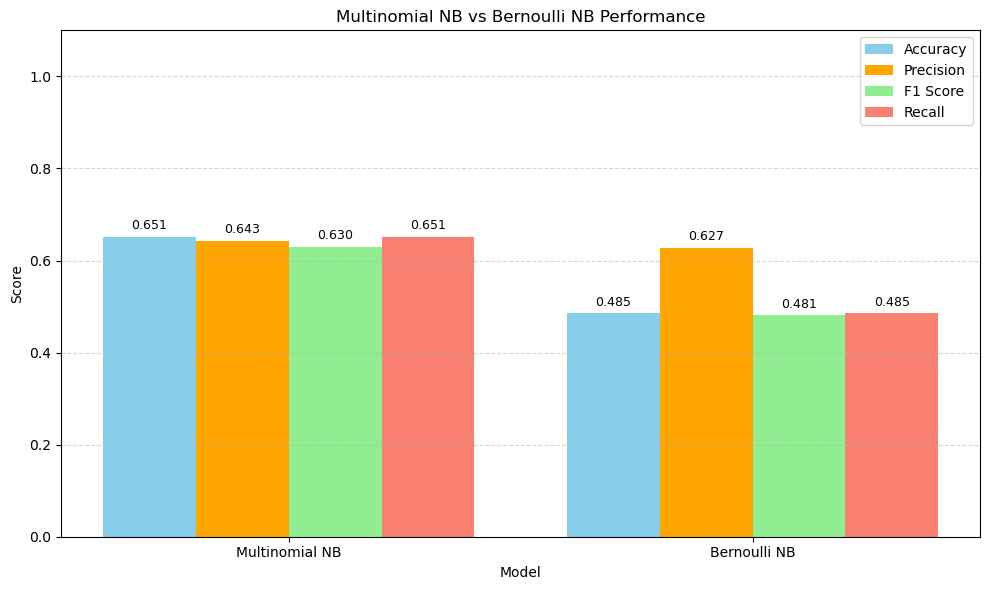

In [26]:

import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "F1 Score", "Recall"]

x = np.arange(len(results["Model"]))
width = 0.2

colors = ["skyblue", "orange", "lightgreen", "salmon"]

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):

    bars = ax.bar(
        x + (i - 1.5) * width,
        results[metric],
        width,
        label=metric,
        color=colors[i]
    )

    # Display numerical values above each bar
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Multinomial NB vs Bernoulli NB Performance")

ax.set_xticks(x)
ax.set_xticklabels(results["Model"])

ax.set_ylim(0, 1.1)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()
